# ANÁLISIS EXPLORATORIO DE DATOS

In [1]:
import kagglehub
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

## Definición del problema

El objetivo es orientar este proyecto como una solución de negocio real.

1. **¿Existen patrones temporales y estacionales claros en el comportamiento de compra de los usuarios?** 
2. **¿Cómo se distribuye el valor del ticket de pago entre los diferentes perfiles de clientes?** 
3. **¿Qué categorías de productos traccionan mejor en determinados momentos del día o temporadas?**
4. **¿Podemos predecir con precisión el segmento de un cliente nuevo con datos de su primera interacción?**

## Recopilación de datos

In [2]:
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Usuario\.cache\kagglehub\datasets\olistbr\brazilian-ecommerce\versions\2


In [3]:
df_customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")
df_geolocation = pd.read_csv("../data/raw/olist_geolocation_dataset.csv")
df_order_items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
df_order_payments = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")
df_order_reviews = pd.read_csv("../data/raw/olist_order_reviews_dataset.csv")
df_orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")
df_products = pd.read_csv("../data/raw/olist_products_dataset.csv")
df_sellers = pd.read_csv("../data/raw/olist_sellers_dataset.csv")
df_product_category_name_translation = pd.read_csv("../data/raw/product_category_name_translation.csv")

In [4]:
df_orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='str')

In [5]:
df_customers.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='str')

In [6]:
# Unir Órdenes con Clientes
df_master = pd.merge(df_orders, df_customers, on="customer_id", how="left")

In [7]:
df_order_items.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='str')

In [8]:
# Unir con los Ítems 
df_master = pd.merge(df_master, df_order_items, on="order_id", how="left")

In [9]:
df_products.columns

Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='str')

In [10]:
# Unir con Productos
df_master = pd.merge(df_master, df_products, on="product_id", how="left")

# Traducir las categorías
df_master = pd.merge(df_master, df_product_category_name_translation, on="product_category_name", how="left")

In [11]:
df_order_payments.head(10)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
5,298fcdf1f73eb413e4d26d01b25bc1cd,1,credit_card,2,96.12
6,771ee386b001f06208a7419e4fc1bbd7,1,credit_card,1,81.16
7,3d7239c394a212faae122962df514ac7,1,credit_card,3,51.84
8,1f78449c87a54faf9e96e88ba1491fa9,1,credit_card,6,341.09
9,0573b5e23cbd798006520e1d5b4c6714,1,boleto,1,51.95


In [12]:
# Unir con df_order_payments solo las columnas de order:id y payment_value
df_master = pd.merge(df_master, df_order_payments[["order_id", "payment_value"]], on="order_id", how="left")

In [13]:
# DataFrame principal
df_master.head(15)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto,179.12
5,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,...,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop,72.20
6,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery,28.62
7,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00,80bb27c7c16e8f973207a5086ab329e2,86320,...,automotivo,49.0,608.0,1.0,7150.0,65.0,10.0,65.0,auto,175.26
8,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00,36edbb3fb164b1f16485364b6fb04c73,98900,...,NaN,NaN,NaN,NaN,600.0,35.0,35.0,15.0,NaN,65.95
9,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07 00:00:00,932afa1e708222e5821dac9cd5db4cae,26525,...,automotivo,59.0,956.0,1.0,50.0,16.0,16.0,17.0,auto,75.16


## Análisis descriptivo

In [14]:
df_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 118434 entries, 0 to 118433
Data columns (total 28 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       118434 non-null  str    
 1   customer_id                    118434 non-null  str    
 2   order_status                   118434 non-null  str    
 3   order_purchase_timestamp       118434 non-null  str    
 4   order_approved_at              118258 non-null  str    
 5   order_delivered_carrier_date   116360 non-null  str    
 6   order_delivered_customer_date  115037 non-null  str    
 7   order_estimated_delivery_date  118434 non-null  str    
 8   customer_unique_id             118434 non-null  str    
 9   customer_zip_code_prefix       118434 non-null  int64  
 10  customer_city                  118434 non-null  str    
 11  customer_state                 118434 non-null  str    
 12  order_item_id                  117604 non

#### Observaciones:
- df_master tiene 118434 registros y 28 características.
- Las características están distribuidas en 11 de tipo flotante, 1 de tipo entero, y 16 de tipo texto.
- Hay 18 columnas de las 28 que poseen valores faltantes.

In [15]:
df_master.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 176
order_delivered_carrier_date     2074
order_delivered_customer_date    3397
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_item_id                     830
product_id                        830
seller_id                         830
shipping_limit_date               830
price                             830
freight_value                     830
product_category_name            2528
product_name_lenght              2528
product_description_lenght       2528
product_photos_qty               2528
product_weight_g                  850
product_length_cm                 850
product_height_cm                 850
product_width_cm                  850
product_cate

## Limpieza de datos

In [16]:
df_master.duplicated().sum()

np.int64(705)

In [17]:
df_master = df_master.drop_duplicates().reset_index(drop=True)
df_master.duplicated().sum()

np.int64(0)

* Se detectaron 705 registros duplicados en el dataset maestro, derivados del proceso de integración de tablas relacionales. Se procedió a su eliminación utilizando `.drop_duplicates()` para garantizar que las métricas no se vean infladas artificialmente durante el análisis.

In [18]:
df_master.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'product_category_name_english', 'payment_value'],
      dtype='str')

In [19]:
df_master.drop(["order_status", "order_approved_at", "order_delivered_carrier_date", "order_estimated_delivery_date", "customer_zip_code_prefix", "customer_city",
                "customer_state", "seller_id", "shipping_limit_date", "freight_value", "product_category_name", "product_name_lenght", 
                "product_description_lenght", "product_photos_qty", "product_weight_g", "product_length_cm", "product_height_cm",
                "product_width_cm", "order_delivered_customer_date", "price", "product_id"], axis=1, inplace=True)

In [20]:
df_master.columns

Index(['order_id', 'customer_id', 'order_purchase_timestamp',
       'customer_unique_id', 'order_item_id', 'product_category_name_english',
       'payment_value'],
      dtype='str')

In [21]:
df_master

,order_id,customer_id,order_purchase_timestamp,customer_unique_id,order_item_id,product_category_name_english,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff,1.0,housewares,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff,1.0,housewares,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff,1.0,housewares,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,af07308b275d755c9edb36a90c618231,1.0,perfumery,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,3a653a41f6f9fc3d2a113cf8398680e8,1.0,auto,179.12
...,...,...,...,...,...,...,...
117724,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,2018-02-06 12:58:58,da62f9e57a76d978d02ab5362c509660,1.0,baby,195.00
117725,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,2017-08-27 14:46:43,737520a9aad80b3fbbdad19b66b37b30,1.0,home_appliances_2,271.01
117726,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,2018-01-08 21:28:27,5097a5312c8b157bb7be58ae360ef43c,1.0,computers_accessories,441.16
117727,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,2018-01-08 21:28:27,5097a5312c8b157bb7be58ae360ef43c,2.0,computers_accessories,441.16


## Análisis de las variables

### Análisis univariante de variables.

In [22]:
df_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 117729 entries, 0 to 117728
Data columns (total 7 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       117729 non-null  str    
 1   customer_id                    117729 non-null  str    
 2   order_purchase_timestamp       117729 non-null  str    
 3   customer_unique_id             117729 non-null  str    
 4   order_item_id                  116918 non-null  float64
 5   product_category_name_english  115224 non-null  str    
 6   payment_value                  117726 non-null  float64
dtypes: float64(2), str(5)
memory usage: 6.3 MB


#### Análisis de la variable `order_id`

In [23]:
df_master["order_id"].value_counts()

order_id
fedcd9f7ccdc8cba3a18defedd1a5547    34
fa65dad1b0e818e3ccc5cb0e39231352    25
a3725dfe487d359b5be08cac48b64ec5    24
465c2e1bee4561cb39e0db8c5993aafc    24
c6492b842ac190db807c15aff21a7dd6    24
                                    ..
880675dff2150932f1601e1c07eadeeb     1
9c5dedf39a927c1b2549525ed64a053c     1
63943bddc261676b46f01ca7ac2f7bd8     1
83c1379a015df1e13d02aae0204711ab     1
66dea50a8b16d9b4dee7af250b4be1a5     1
Name: count, Length: 99441, dtype: int64

In [24]:
#Hay distintas entradas para el mismo id, por cada producto del mismo ticket
df_master[df_master["order_id"] == "fedcd9f7ccdc8cba3a18defedd1a5547"].head(25)

,order_id,customer_id,order_purchase_timestamp,customer_unique_id,order_item_id,product_category_name_english,payment_value
32018,fedcd9f7ccdc8cba3a18defedd1a5547,13aa59158da63ba0e93ec6ac2c07aacb,2017-09-23 14:56:45,6fbc7cdadbb522125f4b27ae9dee4060,1.0,office_furniture,10.66
32019,fedcd9f7ccdc8cba3a18defedd1a5547,13aa59158da63ba0e93ec6ac2c07aacb,2017-09-23 14:56:45,6fbc7cdadbb522125f4b27ae9dee4060,1.0,office_furniture,1.67
32020,fedcd9f7ccdc8cba3a18defedd1a5547,13aa59158da63ba0e93ec6ac2c07aacb,2017-09-23 14:56:45,6fbc7cdadbb522125f4b27ae9dee4060,1.0,office_furniture,5.30
32021,fedcd9f7ccdc8cba3a18defedd1a5547,13aa59158da63ba0e93ec6ac2c07aacb,2017-09-23 14:56:45,6fbc7cdadbb522125f4b27ae9dee4060,1.0,office_furniture,8.42
32022,fedcd9f7ccdc8cba3a18defedd1a5547,13aa59158da63ba0e93ec6ac2c07aacb,2017-09-23 14:56:45,6fbc7cdadbb522125f4b27ae9dee4060,1.0,office_furniture,31.43
32023,fedcd9f7ccdc8cba3a18defedd1a5547,13aa59158da63ba0e93ec6ac2c07aacb,2017-09-23 14:56:45,6fbc7cdadbb522125f4b27ae9dee4060,1.0,office_furniture,7.63
32024,fedcd9f7ccdc8cba3a18defedd1a5547,13aa59158da63ba0e93ec6ac2c07aacb,2017-09-23 14:56:45,6fbc7cdadbb522125f4b27ae9dee4060,1.0,office_furniture,7.76
32025,fedcd9f7ccdc8cba3a18defedd1a5547,13aa59158da63ba0e93ec6ac2c07aacb,2017-09-23 14:56:45,6fbc7cdadbb522125f4b27ae9dee4060,1.0,office_furniture,5.84
32026,fedcd9f7ccdc8cba3a18defedd1a5547,13aa59158da63ba0e93ec6ac2c07aacb,2017-09-23 14:56:45,6fbc7cdadbb522125f4b27ae9dee4060,1.0,office_furniture,9.76
32027,fedcd9f7ccdc8cba3a18defedd1a5547,13aa59158da63ba0e93ec6ac2c07aacb,2017-09-23 14:56:45,6fbc7cdadbb522125f4b27ae9dee4060,1.0,office_furniture,13.27


In [25]:
# Este ticket en cuestion, compró 34 productos de la categoría office_furniture
df_master[df_master["order_id"] == "fedcd9f7ccdc8cba3a18defedd1a5547"]["product_category_name_english"].value_counts()

product_category_name_english
office_furniture    34
Name: count, dtype: int64

In [26]:
# Visualizo df_master sin duplicados en order_id para visualizar la cantidad de compras reales, tickets distintos.
df_master.drop_duplicates(subset=["order_id"])

,order_id,customer_id,order_purchase_timestamp,customer_unique_id,order_item_id,product_category_name_english,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff,1.0,housewares,18.12
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,af07308b275d755c9edb36a90c618231,1.0,perfumery,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,3a653a41f6f9fc3d2a113cf8398680e8,1.0,auto,179.12
5,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,7c142cf63193a1473d2e66489a9ae977,1.0,pet_shop,72.20
6,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,72632f0f9dd73dfee390c9b22eb56dd6,1.0,stationery,28.62
...,...,...,...,...,...,...,...
117723,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,2017-03-09 09:54:05,6359f309b166b0196dbf7ad2ac62bb5a,1.0,health_beauty,85.08
117724,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,2018-02-06 12:58:58,da62f9e57a76d978d02ab5362c509660,1.0,baby,195.00
117725,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,2017-08-27 14:46:43,737520a9aad80b3fbbdad19b66b37b30,1.0,home_appliances_2,271.01
117726,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,2018-01-08 21:28:27,5097a5312c8b157bb7be58ae360ef43c,1.0,computers_accessories,441.16


##### Observaciones:
> - `order_id`: Es la clave única que identifica cada orden. Hay un total de 99441 órdenes realizadas. Puede aparecer el mismo order_id múltiples veces devido a que se genera una fila que representa a cada producto distinto dentro de la misma orden.

#### Análisis de la variable `customer_id`

In [27]:
df_master["customer_id"].value_counts()

customer_id
13aa59158da63ba0e93ec6ac2c07aacb    34
9af2372a1e49340278e7c1ef8d749f34    25
d22f25a9fadfb1abbc2e29395b1239f4    24
63b964e79dee32a3587651701a2b8dbf    24
6ee2f17e3b6c33d6a9557f280edd2925    24
                                    ..
47cd45a6ac7b9fb16537df2ccffeb5ac     1
39bd1228ee8140590ac3aca26f2dfe00     1
1fca14ff2861355f6e5f14306ff977a7     1
1aa71eb042121263aafbe80c1b562c9c     1
edb027a75a1449115f6b43211ae02a24     1
Name: count, Length: 99441, dtype: int64

> - `customer_id`: Presenta los id únicos de las compras realizadas. Se puede observar que el id que tiene más registros suma 21, esto se debe a que los productos de su compra suman un total de 21 y se genera una fila nueva para cada producto.


#### Análsisi de la variable `order_purchase_timestamp`

In [28]:
# Se crea un dataframe sin repeticiones en los registros de `order_id`
df_unique_order = df_master.drop_duplicates("order_id")

In [29]:
# order_purchase_timestamp muestra la fecha con horas y segundos.
df_unique_order["order_purchase_timestamp"].value_counts()

order_purchase_timestamp
2018-03-31 15:08:21    3
2017-11-20 10:59:08    3
2018-08-02 12:06:09    3
2018-08-02 12:05:26    3
2018-02-19 15:37:47    3
                      ..
2017-03-09 09:54:05    1
2018-02-06 12:58:58    1
2017-08-27 14:46:43    1
2018-01-08 21:28:27    1
2018-03-08 20:57:30    1
Name: count, Length: 98875, dtype: int64

In [30]:
# creo una columna solo con la fecha, sin las horas.
df_unique_order["purchase_date"] = pd.to_datetime(df_unique_order["order_purchase_timestamp"]).dt.date

In [31]:
# Visualizo cuantas compras hay en una misma fecha.
df_unique_order["purchase_date"].value_counts()

purchase_date
2017-11-24    1176
2017-11-25     499
2017-11-27     403
2017-11-26     391
2017-11-28     380
              ... 
2018-10-16       1
2018-09-12       1
2016-10-02       1
2018-10-01       1
2018-08-31       1
Name: count, Length: 634, dtype: int64

C:\Users\Usuario\AppData\Local\Temp\ipykernel_7136\976279117.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_unique_order, y="purchase_date", order=df_unique_order["purchase_date"].value_counts().index[:10],


Text(0.5, 0, 'Número de ventas')

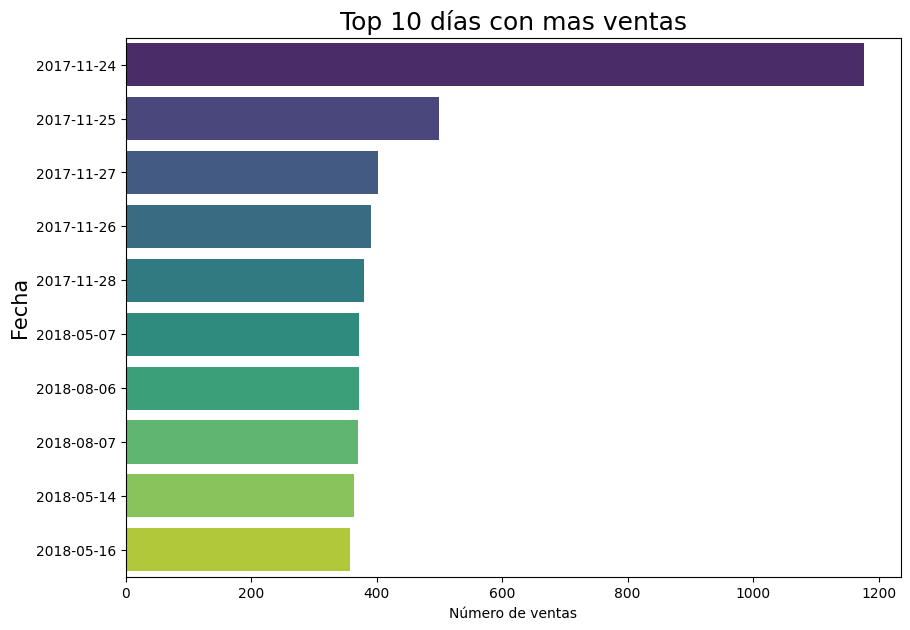

In [32]:
#Grafico de countplot
plt.figure(figsize=(10, 7))
sns.countplot(data=df_unique_order, y="purchase_date", order=df_unique_order["purchase_date"].value_counts().index[:10],
              palette="viridis")
plt.title("Top 10 días con mas ventas", fontsize=18)
plt.ylabel("Fecha", fontsize=15)
plt.xlabel("Número de ventas")

#### Observaciones:
> - **Pico historíco:** Se puede observar que la fecha con más ventas corresponde al 2017-11-24 cercana a 1200 ventas. El día de Black Friday
> - La segunda fecha con más ventas corresponde a 2017-11-25, el dia posterior de Black Friday con una caida en ventas de poco mas de 50% respecto al pico.
> - **Dominio de Noviembre 2017:** El mayor número de ventas se realizarón durante el mes de noviembre y durante el mismo periodo de la semana en el año 2017. Este mes de 2017 representa el top 5 de la gráfica.

#### Análisis de la variable `customer_unique_id`

In [33]:
df_unique_order["customer_unique_id"].value_counts()

customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
ca77025e7201e3b30c44b472ff346268     7
1b6c7548a2a1f9037c1fd3ddfed95f33     7
6469f99c1f9dfae7733b25662e7f1782     7
                                    ..
6359f309b166b0196dbf7ad2ac62bb5a     1
da62f9e57a76d978d02ab5362c509660     1
737520a9aad80b3fbbdad19b66b37b30     1
5097a5312c8b157bb7be58ae360ef43c     1
60350aa974b26ff12caad89e55993bd6     1
Name: count, Length: 96096, dtype: int64

In [34]:
df_unique_order[df_unique_order["customer_unique_id"] =="8d50f5eadf50201ccdcedfb9e2ac8455"]

,order_id,customer_id,order_purchase_timestamp,customer_unique_id,order_item_id,product_category_name_english,payment_value,purchase_date
2759,c2213109a2cc0e75d55585b7aaac6d97,897b7f72042714efaa64ac306ba0cafc,2018-08-07 23:32:14,8d50f5eadf50201ccdcedfb9e2ac8455,1.0,sports_leisure,34.44,2018-08-07
4257,23427a6bd9f8fd1b51f1b1e5cc186ab8,a8fabc805e9a10a3c93ae5bff642b86b,2018-05-21 22:44:31,8d50f5eadf50201ccdcedfb9e2ac8455,1.0,sports_leisure,53.38,2018-05-21
6019,e3071b7624445af6e4f3a1b23718667d,0bf8bf19944a7f8b40ba86fef778ca7c,2017-09-05 22:14:52,8d50f5eadf50201ccdcedfb9e2ac8455,1.0,sports_leisure,51.75,2017-09-05
13718,d3582fd5ccccd9cb229a63dfb417c86f,a682769c4bc10fc6ef2101337a6c83c9,2018-08-20 19:14:26,8d50f5eadf50201ccdcedfb9e2ac8455,1.0,costruction_tools_tools,38.66,2018-08-20
19102,5837a2c844decae8a778657425f6d664,31dd055624c66f291578297a551a6cdf,2017-07-17 22:11:13,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,NaN,25.59,2017-07-17
22555,bf92c69b7cc70f7fc2c37de43e366173,42dbc1ad9d560637c9c4c1533746f86d,2017-07-24 22:11:50,8d50f5eadf50201ccdcedfb9e2ac8455,1.0,sports_leisure,166.71,2017-07-24
29416,6bdf325f0966e3056651285c0aed5aad,6289b75219d757a56c0cce8d9e427900,2018-05-22 23:08:55,8d50f5eadf50201ccdcedfb9e2ac8455,1.0,sports_leisure,62.95,2018-05-22
39958,4f62d593acae92cea3c5662c76122478,dfb941d6f7b02f57a44c3b7c3fefb44b,2017-07-18 23:10:58,8d50f5eadf50201ccdcedfb9e2ac8455,1.0,fashion_bags_accessories,21.77,2017-07-18
46721,b850a16d8faf65a74c51287ef34379ce,1bd3585471932167ab72a84955ebefea,2017-11-22 20:01:53,8d50f5eadf50201ccdcedfb9e2ac8455,1.0,sports_leisure,21.77,2017-11-22
69514,519203404f6116d406a970763ee75799,1c62b48fb34ee043310dcb233caabd2e,2017-08-05 08:59:43,8d50f5eadf50201ccdcedfb9e2ac8455,1.0,NaN,81.89,2017-08-05


#### Observaciones:
> - `customer_unique_id`: Es la clave única del cliente, esta clave se repite en el dataframe por cada orden que se ha realizado.
> - El cliente recurrente que acumula más ordenes, ha realizado 17 ordenes distintas.

#### Análisis de la variable `product_category_name_english`

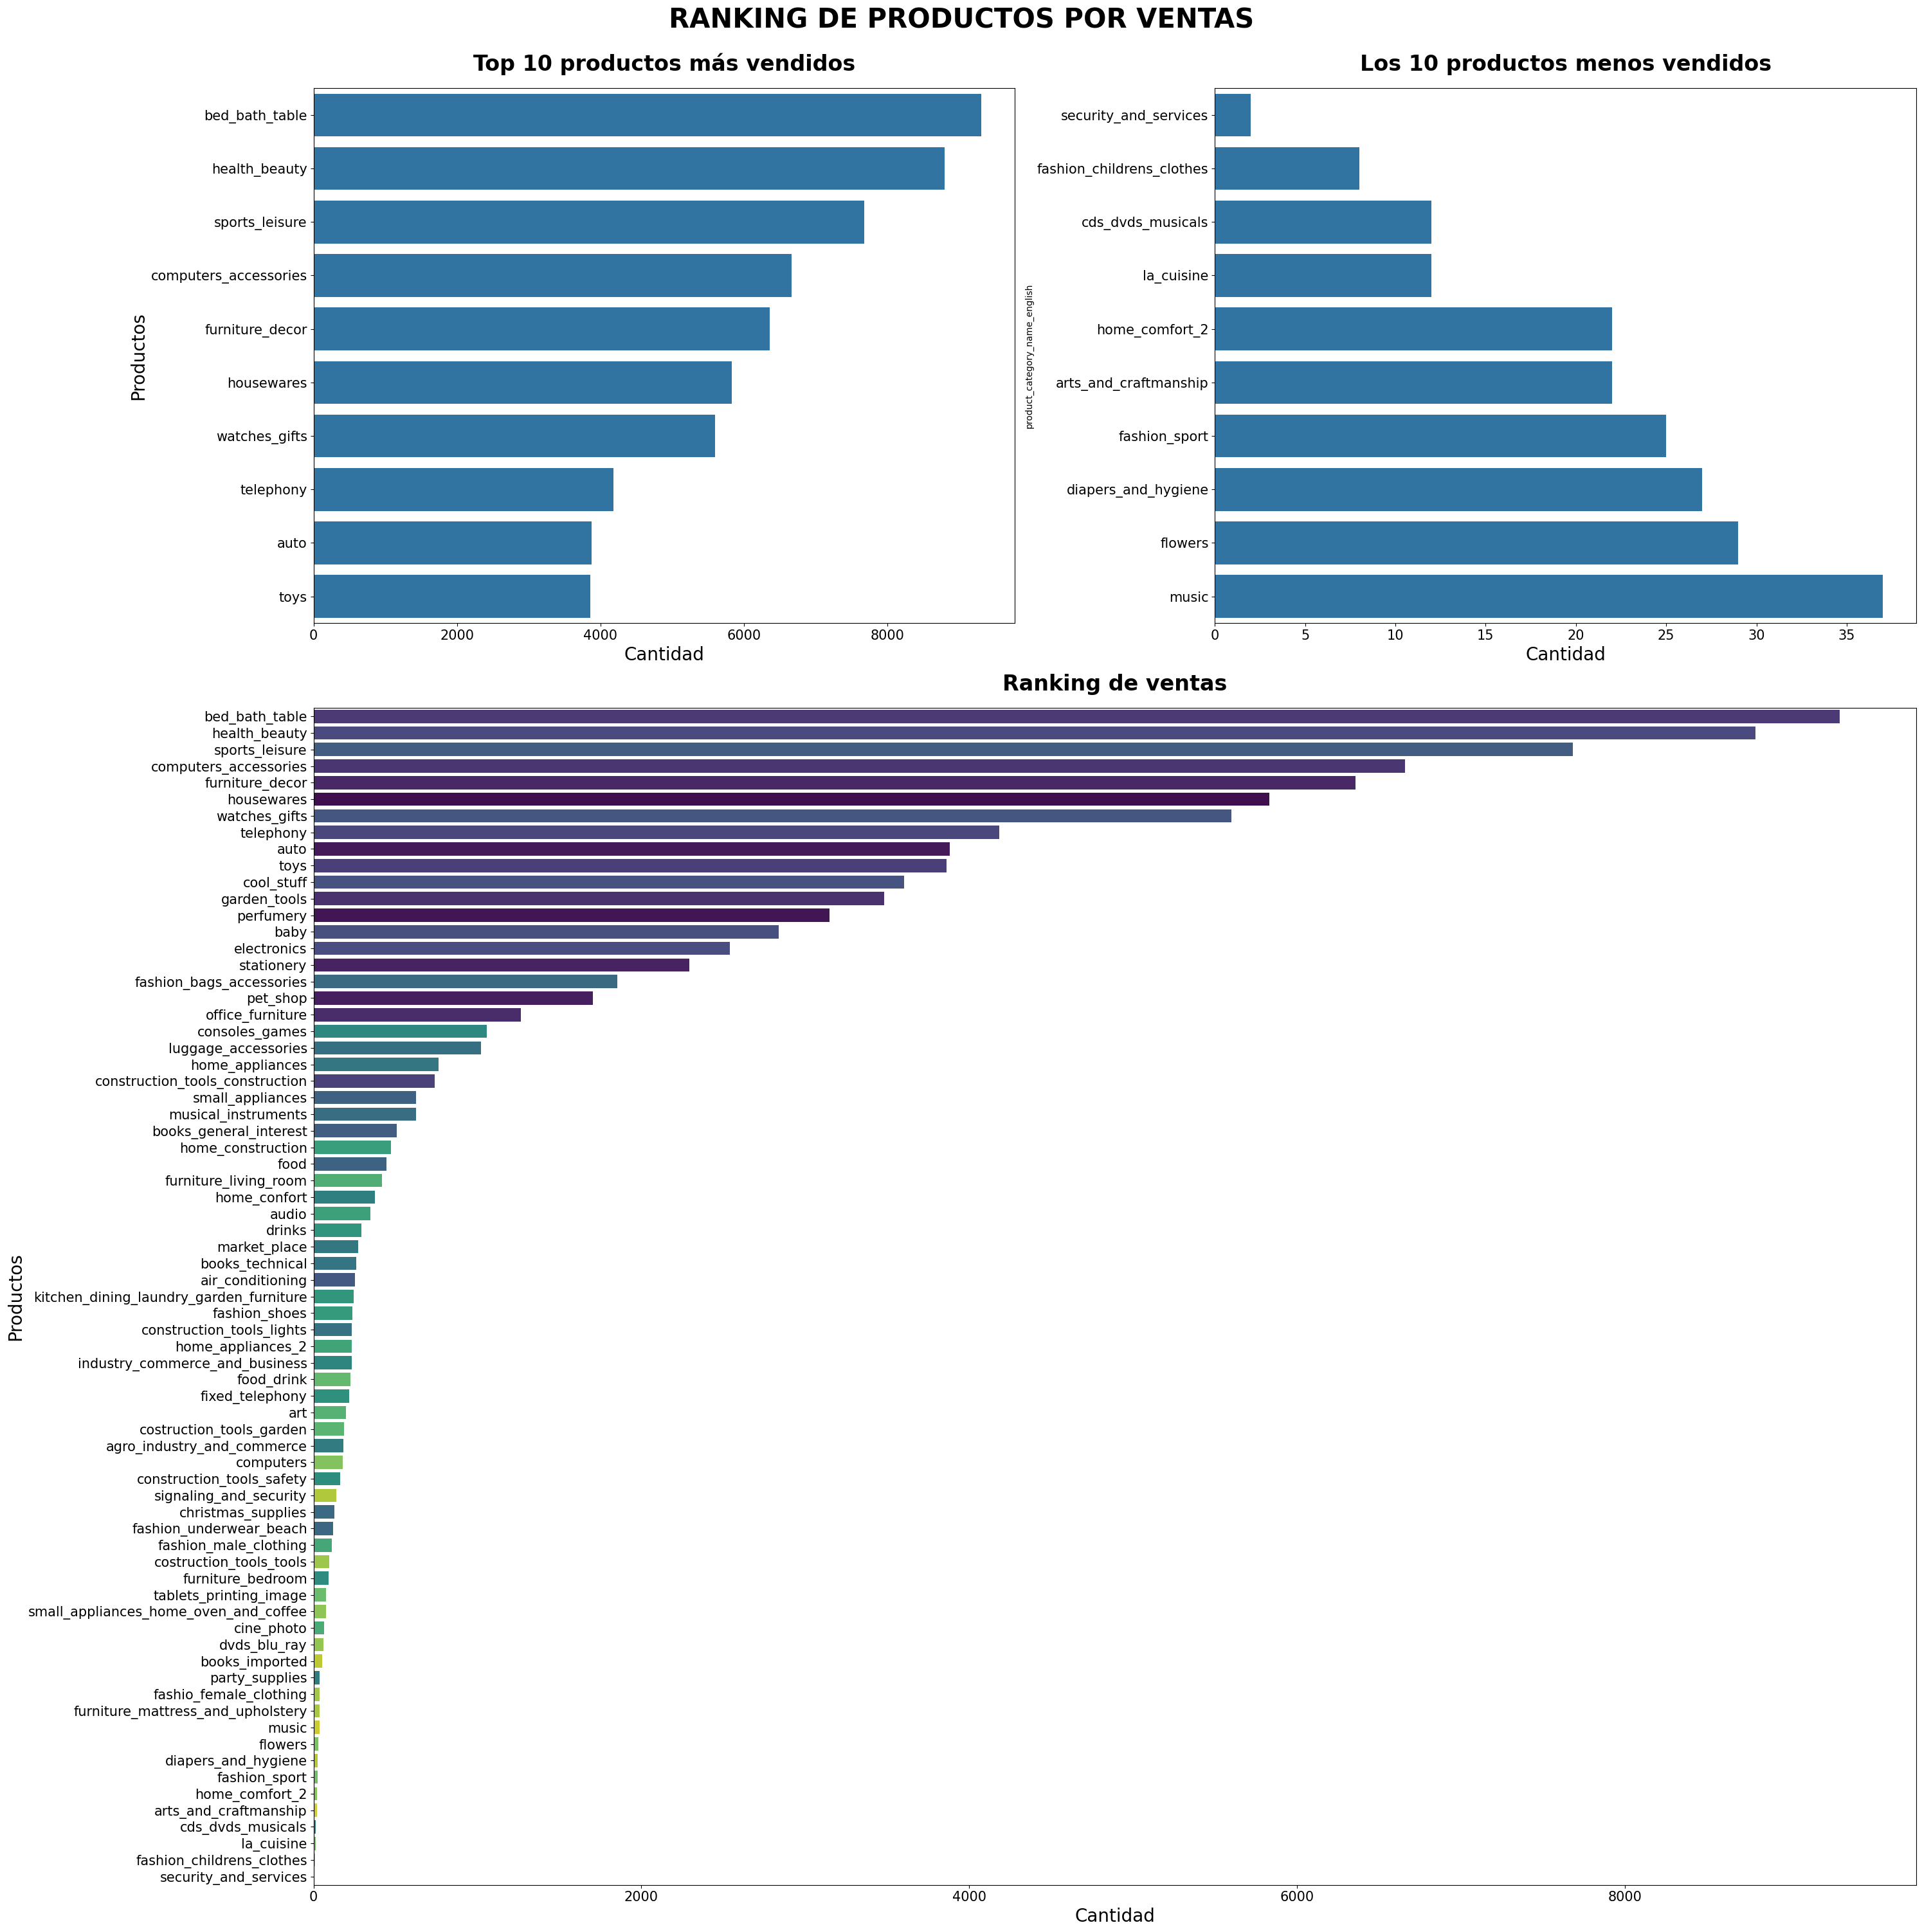

In [35]:
mosaic = [["A", "B"], 
          ["C", "C"]]

fig, axis = plt.subplot_mosaic(mosaic, figsize=(30,30), gridspec_kw={'height_ratios': [1, 2.20]})
fig.suptitle("RANKING DE PRODUCTOS POR VENTAS", fontsize=30, fontweight="bold", y=1)

sns.countplot(ax=axis["A"],data=df_unique_order, y="product_category_name_english", 
              order=df_unique_order["product_category_name_english"].value_counts().head(10).index)
axis["A"].set_title("Top 10 productos más vendidos", size=24, weight='bold', pad=20)
axis["A"].set_ylabel("Productos", size=20)
axis["A"].set_xlabel("Cantidad", size=20)
axis["A"].tick_params(labelsize=15)


sns.countplot(ax=axis["B"],data=df_unique_order, y="product_category_name_english", 
              order=df_unique_order["product_category_name_english"].value_counts().tail(10).sort_values(ascending=True).index)
axis["B"].set_title("Los 10 productos menos vendidos", size=24, weight='bold', pad=20)
axis["B"].set_xlabel("Cantidad", size=20)
axis["B"].tick_params(labelsize=15)

sns.countplot(ax=axis["C"],data=df_unique_order, y="product_category_name_english", 
              order=df_unique_order["product_category_name_english"].value_counts().index,
              hue="product_category_name_english" ,palette="viridis", legend=False)
axis["C"].set_title("Ranking de ventas", size=24, weight='bold', pad=20)
axis["C"].set_ylabel("Productos", size=20)
axis["C"].set_xlabel("Cantidad", size=20)
axis["C"].tick_params(labelsize=15)

plt.tight_layout()


#### Observaciones:
> - Los productos relacionados con el hogar y el bienestar están en el top ventas con más de 8000 registros, seguidos de cerca por deporte y ocio.
> - Existe una diferencia de ventas extrema, mientras que la categoría más vendida supera los 8000 registros, las categoría menos vendida como seguridad y servicio, apenas supera los 20.
> - El ranking de ventas se concentra entre las 16 primeras categorías, a partir de la categoría stationery se observa una caída de ventas más pronunciada.

### Análisis de variables numéricas

#### Análisis de la variable `order_item_id`

In [36]:
df_master["order_item_id"].value_counts()

order_item_id
1.0     102461
2.0      10178
3.0       2352
4.0        984
5.0        468
6.0        261
7.0         59
8.0         36
9.0         28
10.0        25
11.0        17
12.0        13
13.0         8
14.0         7
15.0         5
16.0         3
17.0         3
18.0         3
19.0         3
20.0         3
21.0         1
Name: count, dtype: int64

### Visualización recuento de proudctos

Text(0, 0.5, 'Cantidad de Órdenes')

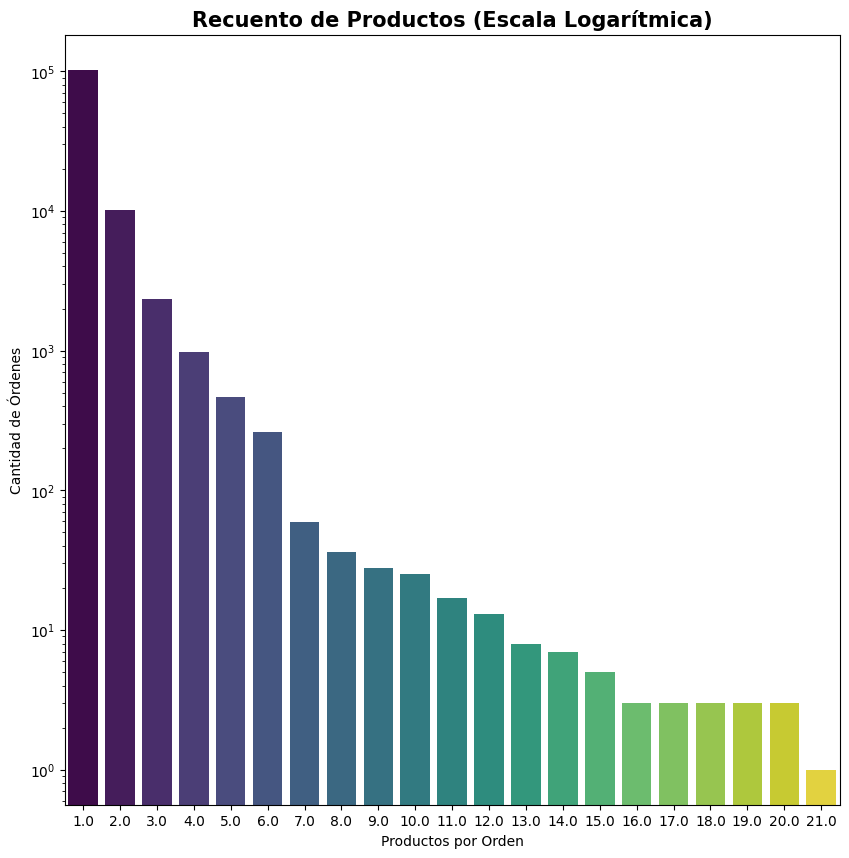

In [37]:
plt.figure(figsize=(10,10))

# Generamos la gráfica
ax = sns.countplot(data=df_master, x="order_item_id", hue="order_item_id", palette="viridis", legend=False)

# Aplicar escala logarítmica en el eje X (Cantidad)
ax.set_yscale("log")

plt.title("Recuento de Productos (Escala Logarítmica)", fontsize=15, fontweight='bold')
plt.xlabel("Productos por Orden")
plt.ylabel("Cantidad de Órdenes")

##### Observaciones:
> - En la gráfica se observa una distribución con la moda muy marcada en el valor 1; la mayoría de compras que se realizan constan de un único producto, seguido de compras con 2 productos y así de forma decreciente llegando a pedidos donde hay un total de 21 productos.


### Análisis de la variable `payment_value`

In [38]:
df_unique_order["payment_value"].sort_values(ascending=False)

15713    13664.08
78752     7274.88
26168     6929.31
33549     6922.21
4090      6726.66
           ...   
84786        0.01
1347         0.00
47274        0.00
47650        0.00
36410         NaN
Name: payment_value, Length: 99441, dtype: float64

In [39]:
df_unique_order["payment_value"].value_counts().head(10)

payment_value
77.57     250
50.00     161
35.00     161
73.34     160
116.94    131
56.78     122
100.00    117
107.78    116
65.00     116
99.90     107
Name: count, dtype: int64

### Visualización de pagos


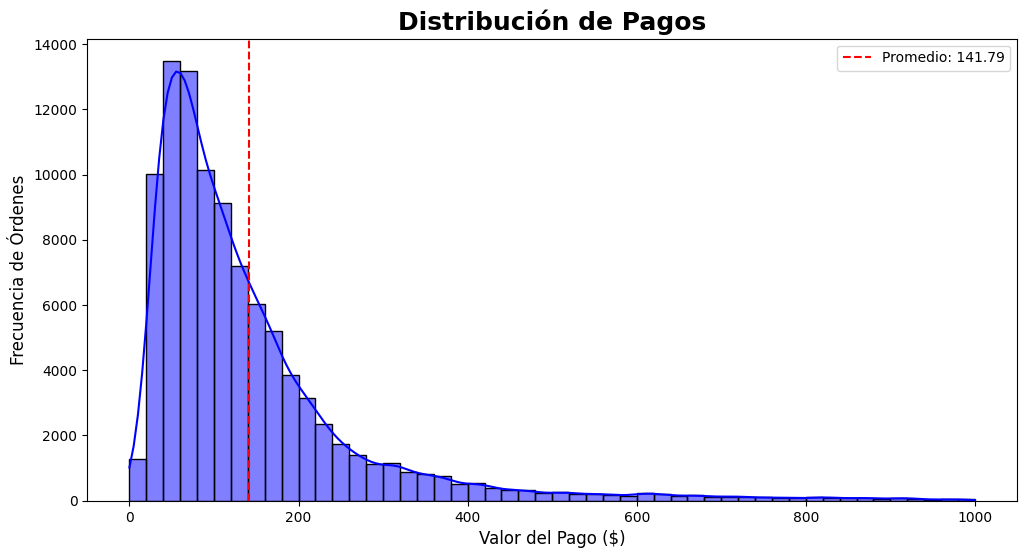

In [40]:
df_filtered = df_unique_order[df_unique_order["payment_value"] < 1000]["payment_value"]
               
mean_val = df_filtered.mean()

plt.figure(figsize=(12, 6))

sns.histplot(df_filtered,color="blue", bins=50, kde=True)

plt.title("Distribución de Pagos", fontsize=18, fontweight='bold')
plt.xlabel("Valor del Pago ($)", fontsize=12)
plt.ylabel("Frecuencia de Órdenes", fontsize=12)

plt.axvline(mean_val, color='red', linestyle='--', label=f'Promedio: {mean_val:.2f}')
plt.legend()


##### Observaciones:

> -  `payment_value`: Muestra el precio de las órdenes realizadas.
> - La gráfica muestra una distribución unimodal  de sesgo positivo con la moda en el valor de 77, es el precio que más se repite en las órdenes, seguido de 50.00. La mayoría de las ventas se concentran por debajo de los 200 La frecuencia decrece de forma constante a medida que aumenta el precio de la orden.
> - El valor más alto de una compra realizada es de 13664.08, seguido de 7274.88.
> - Se muestran órdenes cuyo valor es 0, esto se debe a que la orden pudo ser pagada con cupones y no se aportó dinero del cliente.

## Análisis de variables multivariante

### Análisis: Númerica - Númerica

In [41]:
df_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 117729 entries, 0 to 117728
Data columns (total 7 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       117729 non-null  str    
 1   customer_id                    117729 non-null  str    
 2   order_purchase_timestamp       117729 non-null  str    
 3   customer_unique_id             117729 non-null  str    
 4   order_item_id                  116918 non-null  float64
 5   product_category_name_english  115224 non-null  str    
 6   payment_value                  117726 non-null  float64
dtypes: float64(2), str(5)
memory usage: 6.3 MB


#### Análisis de las variables: `payment_value` y `order_item_id`

##### Visualizaciones

<Axes: >

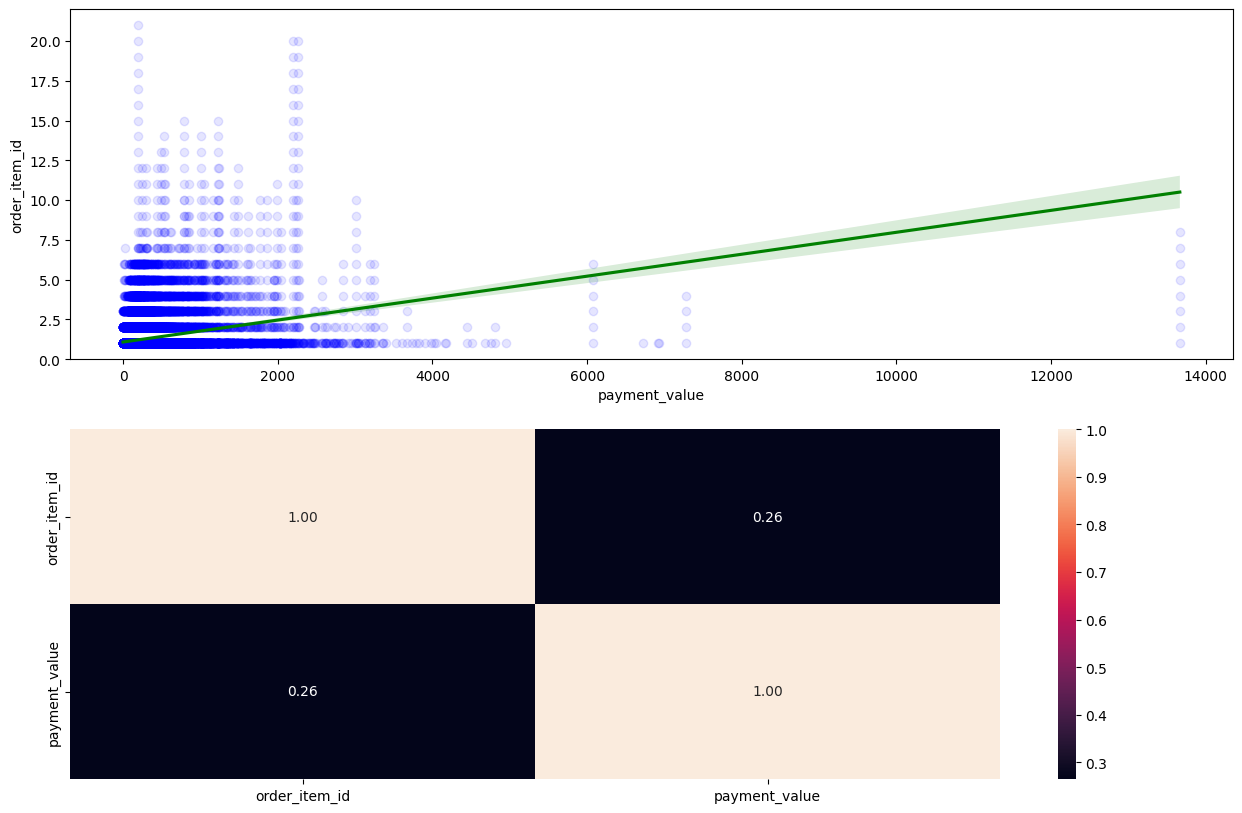

In [42]:
corr_price = df_master[["order_item_id", "payment_value"]].corr()

fig, axis = plt.subplots(2, 1, figsize=(15, 10))
sns.regplot(ax=axis[0], data=df_master, x="payment_value", y="order_item_id",
            scatter_kws={"alpha":0.1, "color":"blue"}, line_kws={"color":"green"})
sns.heatmap(ax=axis[1], data=corr_price, annot=True, fmt=".2f")

#### Observaciones
> - En el gráfico se puede observar en puntos azules una zona de alta densidad que representa el perfil de transacción tipico se caracterizan por tener un precio final que varía de 0 a 2500 con una cantidad de productos de 1 a 6.
> - Hay outliers extremos en ventas con precios próximos a los 14000 con menos de 10 artículos y tickets y compras de 15 a 20 artículos en los que el precio de la venta es 0 lo que sugiere un uso intensivo de cupones de descuento
> - La gráfica de correlación muestra una relación lineal positiva débil, porque el precio total de la compra aumenta debido a la cantidad de productos en un mismo ticket pero depende mucho del precio por unidad del producto.

Text(0, 0.5, 'Cantidad de Productos en la Orden')

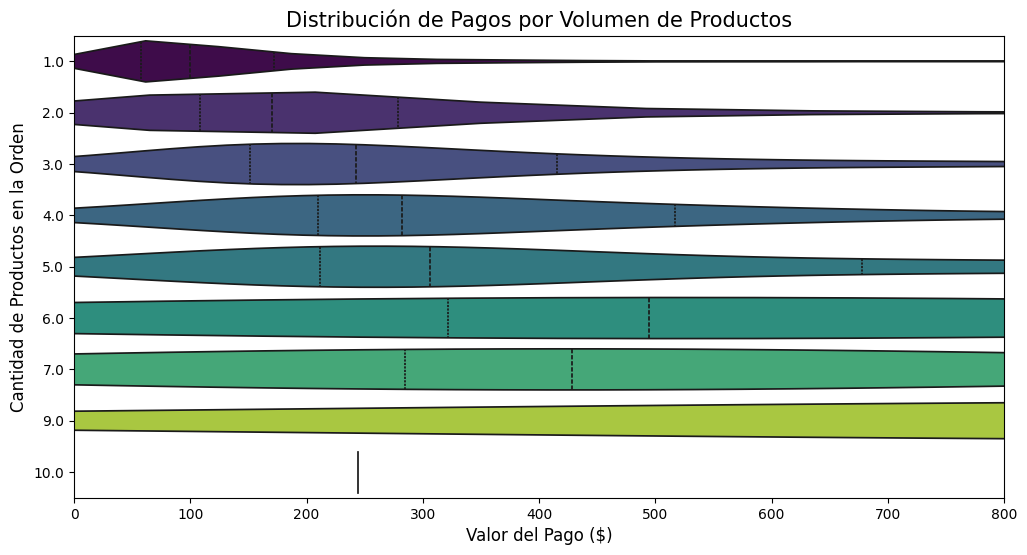

In [43]:
# Realizo un sample
df_master_sample = df_master.sample(15000)

# Filtro para ver los grupos igual o de menores a 10 productos
df_plot = df_master_sample[df_master_sample["order_item_id"] <= 10].copy()

plt.figure(figsize=(12, 6))

sns.violinplot(data=df_plot, x="payment_value", y="order_item_id", 
               palette="viridis", inner="quartile", orient="h",
               hue="order_item_id", legend=False)

plt.xlim(0, 800) 
plt.title("Distribución de Pagos por Volumen de Productos", fontsize=15)
plt.xlabel("Valor del Pago ($)", fontsize=12)
plt.ylabel("Cantidad de Productos en la Orden", fontsize=12)

##### Observaciones:
> - La gráfica violinplot muestra como se concentra o distribuye 
> - Se muestran grupos de una cantidad considerable de productos que indican un precio 0, esto se debe a que fueron pagados con bonos.
> - El mapa de calor nos indica que hay una correlación positiva pero débil con un coeficiente de 0.26.
> - La gráfica de violín, muestra que a mayor cantidad de productos por orden la mediana del precio de la orden aumenta de forma progresiva para cada grupo. Esto confirma la correlación positiva entre ambas variables.
> - Al crecer el número de productos por orden, el violín se estira, esto indica que el comportamiento del precio es más variado.

### Análisis categórica- categórica

In [44]:
df_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 117729 entries, 0 to 117728
Data columns (total 7 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       117729 non-null  str    
 1   customer_id                    117729 non-null  str    
 2   order_purchase_timestamp       117729 non-null  str    
 3   customer_unique_id             117729 non-null  str    
 4   order_item_id                  116918 non-null  float64
 5   product_category_name_english  115224 non-null  str    
 6   payment_value                  117726 non-null  float64
dtypes: float64(2), str(5)
memory usage: 6.3 MB


Text(0.5, 1.0, 'Concentración del Mercado por Categoría')

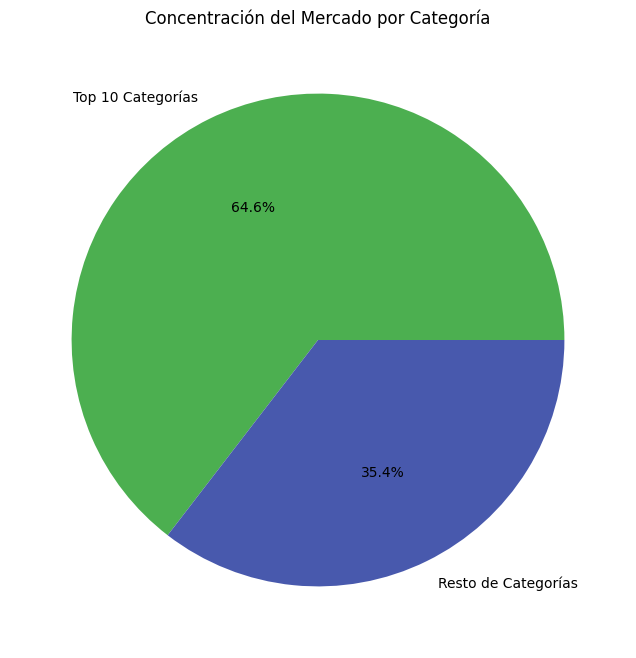

In [45]:
# Obtener las frecuencias
counts = df_master['product_category_name_english'].value_counts(normalize=True)

# Separo el Top 10 del resto
top_10_sum = counts.head(10).sum()
others_sum = counts.iloc[10:].sum()

# Creo un pequeño DataFrame para graficar
dominancia = pd.DataFrame({
    'Grupo': ['Top 10 Categorías', 'Resto de Categorías'],
    'Proporción': [top_10_sum, others_sum]
})

# 4. Gráfico de pastel
plt.figure(figsize=(8, 8))
plt.pie(dominancia['Proporción'], labels=dominancia['Grupo'], autopct='%1.1f%%', colors=['#4CAF50', "#4859AD"])
plt.title('Concentración del Mercado por Categoría')

#### Análisis de variables: Numérico - Categórico

In [46]:
# precio promedio real por cada nombre de categoría
df_master.groupby('product_category_name_english')['payment_value'].mean().sort_values(ascending=False)

product_category_name_english
computers                                1293.300791
fixed_telephony                           763.875498
small_appliances_home_oven_and_coffee     656.786154
home_appliances_2                         481.273450
agro_industry_and_commerce                476.755863
                                            ...     
fashion_underwear_beach                    90.978345
food                                       88.904425
cds_dvds_musicals                          85.673571
flowers                                    67.060909
home_comfort_2                             55.178710
Name: payment_value, Length: 71, dtype: float64

C:\Users\Usuario\AppData\Local\Temp\ipykernel_7136\1557398083.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_top_means.index, y=df_top_means.values, palette="viridis")


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'computers'),
  Text(1, 0, 'fixed_telephony'),
  Text(2, 0, 'small_appliances_home_oven_and_coffee'),
  Text(3, 0, 'home_appliances_2'),
  Text(4, 0, 'agro_industry_and_commerce'),
  Text(5, 0, 'office_furniture'),
  Text(6, 0, 'signaling_and_security'),
  Text(7, 0, 'musical_instruments'),
  Text(8, 0, 'construction_tools_safety'),
  Text(9, 0, 'small_appliances')])

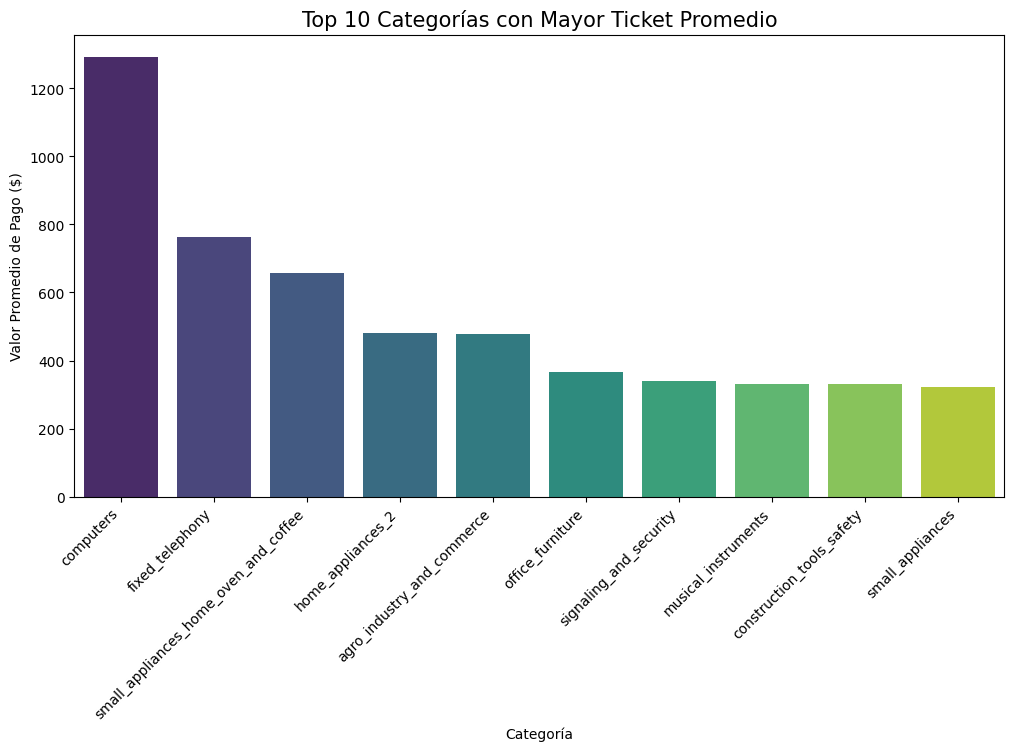

In [47]:
# Preparar los datos
df_top_means = df_master.groupby('product_category_name_english')['payment_value'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))

sns.barplot(x=df_top_means.index, y=df_top_means.values, palette="viridis")

plt.title("Top 10 Categorías con Mayor Ticket Promedio", fontsize=15)
plt.ylabel("Valor Promedio de Pago ($)")
plt.xlabel("Categoría")
plt.xticks(rotation=45, ha='right')

## Conclusiones

## Guardar EDA

In [48]:
output_path = "../data/processed/olist_eda.csv"

df_master.to_csv(output_path, index=False)
print(f"Datos guardados en: {output_path}")

Datos guardados en: ../data/processed/olist_eda.csv
